Citations: Andrew Lucas: Ising formulations of many NP Problems. arXiv:1302.5843. 
https://arxiv.org/abs/1302.5843

Ising machine: Knapsack with Integer Weights

List of N objects with weights M(i), value c(i). Knapsack can only carry object
weight W. NP-hard problem is to maximize value C of items placed in knapsack
with the constraint that the items weight combined <W.


Hamiltonian penalty terms:

1. weight must not exceed W
2. incentivise maximum value c of items

required condition 0 < B(c(max))<A. i.e violating weight condition is heavily
penalised.

[potential future optimization]
Two spin vectors:
1. x: x[n] is 1 if n is in knapsack, 0 otherwise.
2. y: len(y) is max possible weight of knapsack. y[n] = 1 if total weighs n, 0
   otherwise. Should only be one 1.

and first penalty term is only one total weight from y (total weight) is allowed and must match the
   weight of the combined items in knapsack (1 in x).

Lots to improve on here!!

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# ---- Hamiltonian Penalty Terms ----

def get_ha(weights, W, x, A):
    """Penalise exceeding knapsack capacity."""
    total_weight = np.sum(weights * x)
    overweight = max(0, total_weight - W)
    return A * overweight ** 2

def get_hb(values, x, B):
    """Reward for total value (more negative = better)."""
    return -B * np.sum(values * x)

def calc_energy(weights, values, W, x, A, B):
    return get_ha(weights, W, x, A) + get_hb(values, x, B)

In [11]:
# ---- Metropolis / Simulated Annealing ----

def metropolis(weights, values, W, x, A, B, T_start, steps):
    N = len(x)
    x = x.copy()
    energy = calc_energy(weights, values, W, x, A, B)
    best_x = x.copy()
    best_energy = energy

    for step in range(steps):
        j = np.random.randint(0, N)
        x[j] = 1 - x[j]

        new_energy = calc_energy(weights, values, W, x, A, B)
        delta_energy = new_energy - energy

        T = T_start / (1 + step * 0.001)
        if delta_energy < 0 or np.random.rand() < np.exp(-delta_energy / T):
            energy = new_energy
            if energy < best_energy:
                best_energy = energy
                best_x = x.copy()
        else:
            x[j] = 1 - x[j]

    return best_x, best_energy

In [12]:
# ---- Verification ----

def verify_knapsack(weights, values, W, x):
    """Check that selected items fit in the knapsack."""
    selected = [i for i in range(len(x)) if x[i] == 1]
    total_weight = sum(weights[i] for i in selected)
    total_value = sum(values[i] for i in selected)

    if total_weight > W:
        print(f"INVALID: total weight {total_weight} exceeds capacity {W}")
        return False

    print(f"VALID knapsack: items {selected}, weight {total_weight}/{W}, value {total_value}")
    return True

In [13]:
# ---- Plotting ----

def plot_knapsack(weights, values, W, x):
    N = len(x)
    selected = [i for i in range(N) if x[i] == 1]
    not_selected = [i for i in range(N) if x[i] == 0]

    fig, ax = plt.subplots(figsize=(10, 5))

    # draw each item as a box (width = weight, height = value)
    x_pos = 0
    for i in range(N):
        colour = 'steelblue' if x[i] == 1 else 'lightgray'
        edge = 'black' if x[i] == 1 else 'gray'
        rect = plt.Rectangle((x_pos, 0), weights[i], values[i],
                              facecolor=colour, edgecolor=edge, linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x_pos + weights[i] / 2, values[i] / 2,
                f"i={i}\nw={weights[i]}\nv={values[i]}",
                ha='center', va='center', fontsize=9,
                color='white' if x[i] == 1 else 'darkgray')
        x_pos += weights[i] + 0.3

    # draw capacity line
    total_weight = sum(weights[i] for i in selected)
    total_value = sum(values[i] for i in selected)

    ax.set_xlim(-0.5, x_pos)
    ax.set_ylim(-0.5, max(values) + 1)
    ax.set_xlabel('Weight')
    ax.set_ylabel('Value')
    ax.set_title(f"Knapsack (capacity {W}): selected items {selected}, "
                 f"weight {total_weight}/{W}, value {total_value}")
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

In [14]:
# ---- Example 1: Small instance with known solution ----
# Items: 4 items, capacity 7
# Optimal: items {1,2} or {0,3} with value 9

weights = np.array([2, 3, 4, 5])
values  = np.array([3, 4, 5, 6])
W = 7

print(f"Knapsack capacity: {W}")
for i in range(len(weights)):
    print(f"  Item {i}: weight={weights[i]}, value={values[i]}")
print(f"Optimal value: 9 (items {{1,2}} weight 7, or items {{0,3}} weight 7)")

Knapsack capacity: 7
  Item 0: weight=2, value=3
  Item 1: weight=3, value=4
  Item 2: weight=4, value=5
  Item 3: weight=5, value=6
Optimal value: 9 (items {1,2} weight 7, or items {0,3} weight 7)


Energy: -9.0
H_A (should be 0): 0.0
H_B (value reward): -9.0
VALID knapsack: items [0, 3], weight 7/7, value 9


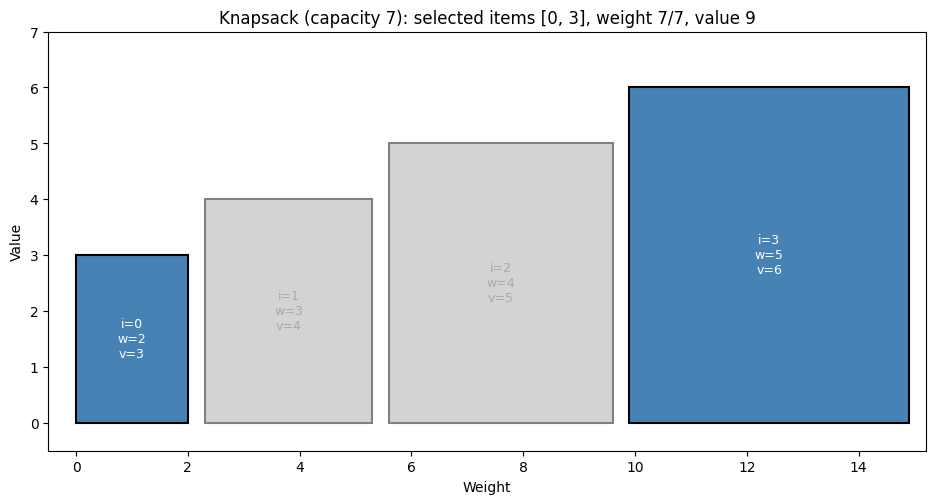

In [15]:
N = len(weights)
A = 10.0
B = 1.0  # B * c_max = 6 < A = 10
T_start = 5.0
steps = 200000

x = np.random.randint(2, size=N)
best_x, best_energy = metropolis(weights, values, W, x, A, B, T_start, steps)

print(f"Energy: {best_energy}")
print(f"H_A (should be 0): {get_ha(weights, W, best_x, A)}")
print(f"H_B (value reward): {get_hb(values, best_x, B)}")
verify_knapsack(weights, values, W, best_x)
plot_knapsack(weights, values, W, best_x)

Knapsack: 15 items, capacity 23
  Item 0: weight=1, value=12, ratio=12.00
  Item 1: weight=3, value=16, ratio=5.33
  Item 2: weight=8, value=17, ratio=2.12
  Item 3: weight=1, value=16, ratio=16.00
  Item 4: weight=1, value=5, ratio=5.00
  Item 5: weight=1, value=16, ratio=16.00
  Item 6: weight=3, value=13, ratio=4.33
  Item 7: weight=5, value=5, ratio=1.00
  Item 8: weight=3, value=11, ratio=3.67
  Item 9: weight=2, value=5, ratio=2.50
  Item 10: weight=7, value=4, ratio=0.57
  Item 11: weight=9, value=1, ratio=0.11
  Item 12: weight=3, value=17, ratio=5.67
  Item 13: weight=7, value=8, ratio=1.14
  Item 14: weight=4, value=15, ratio=3.75

Energy: -126.0
H_A (should be 0): 0.0
H_B (value reward): -126.0
VALID knapsack: items [0, 1, 3, 4, 5, 6, 8, 9, 12, 14], weight 22/23, value 126


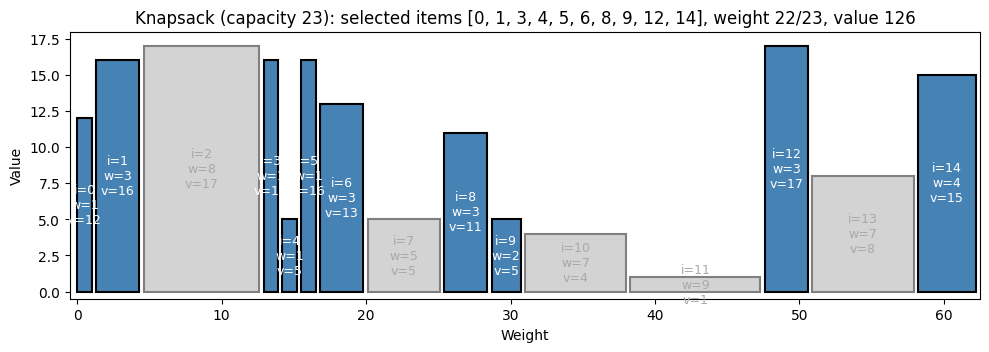

In [16]:
# ---- Example 2: Larger random instance ----

N = 15
weights = np.random.randint(1, 10, size=N)
values = np.random.randint(1, 20, size=N)
W = int(np.sum(weights) * 0.4)  # capacity ~ 40% of total weight

print(f"Knapsack: {N} items, capacity {W}")
for i in range(N):
    print(f"  Item {i}: weight={weights[i]}, value={values[i]}, ratio={values[i]/weights[i]:.2f}")

A = 10.0
B = 1.0
T_start = 10.0
steps = 500000

x = np.random.randint(2, size=N)
best_x, best_energy = metropolis(weights, values, W, x, A, B, T_start, steps)

print(f"\nEnergy: {best_energy}")
print(f"H_A (should be 0): {get_ha(weights, W, best_x, A)}")
print(f"H_B (value reward): {get_hb(values, best_x, B)}")
verify_knapsack(weights, values, W, best_x)
plot_knapsack(weights, values, W, best_x)